In [44]:
# Import libraries
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense

In [45]:
# Load dataset

(x_train,y_train),(x_test,y_test) = imdb.load_data(num_words = 10000)

In [46]:
# Dataset shape

print(x_train.shape)
print(x_test.shape)

print(y_train.shape)
print(y_test.shape)

(25000,)
(25000,)
(25000,)
(25000,)


In [47]:
# View first review

print(x_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [48]:
# View first label

print(y_train[0])

1


1 ---> positive review

0 ---> negative review

In [49]:
# Pad sequences

x_train = pad_sequences(
    x_train,
    maxlen=500
)

x_test = pad_sequences(
    x_test,
    maxlen=500
)

In [50]:
# After padding

print(x_train.shape)
print(x_test.shape)

(25000, 500)
(25000, 500)


In [51]:
# Build RNN Model

# Create model

model = Sequential()

In [52]:
# Embedding layer

model.add(
    Embedding(
        input_dim=10000,
        output_dim=32,
        input_length=500
    )
)

In [53]:
# Simple RNN layer

model.add(
    SimpleRNN(
        32,
        activation='relu'
    )
)

In [54]:
# Output layer

model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

In [55]:
model.build(input_shape=(None, 500))

In [56]:
# Model summary

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
# Compile model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [58]:
# Train model

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 110s 325ms/step - accuracy: 0.5837 - loss: 1.1857 - val_accuracy: 0.6266 - val_loss: 0.6351
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 154s 490ms/step - accuracy: 0.6771 - loss: 2260495499264.0000 - val_accuracy: 0.6310 - val_loss: 0.6215
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 147s 315ms/step - accuracy: 0.7122 - loss: 0.5749 - val_accuracy: 0.6398 - val_loss: 0.6119
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 240ms/step - accuracy: 0.7358 - loss: 0.5441 - val_accuracy: 0.6438 - val_loss: 0.6081
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 256ms/step - accuracy: 0.7481 - loss: 0.5157 - val_accuracy: 0.6486 - val_loss: 0.6082


In [59]:
# Evaluate model

loss, accuracy = model.evaluate(
    x_test,
    y_test
)

print("Loss :", loss)
print("Accuracy :", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.6483 - loss: 47358730240.0000
Loss : 47358730240.0
Accuracy : 0.6482800245285034


In [60]:
# Prediction

prediction = model.predict(x_test)

print(prediction)

782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 55ms/step
[[0.43053737]
 [0.807562  ]
 [0.07263107]
 ...
 [0.38759065]
 [0.2938379 ]
 [0.7469926 ]]


In [61]:
# Convert probabilities

predicted_label = (prediction > 0.5)

print(predicted_label)

[[False]
 [ True]
 [False]
 ...
 [False]
 [False]
 [ True]]


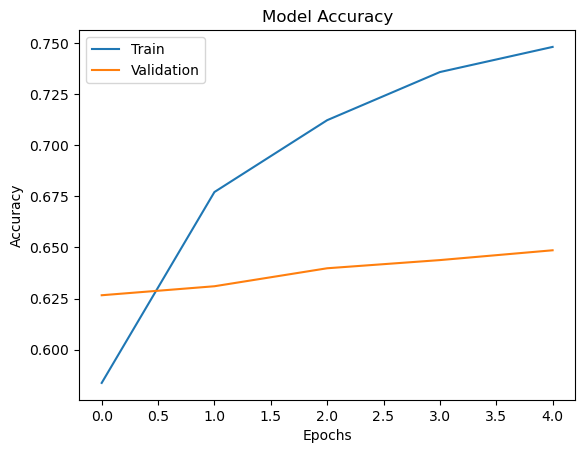

In [62]:
# Plot training accuracy

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

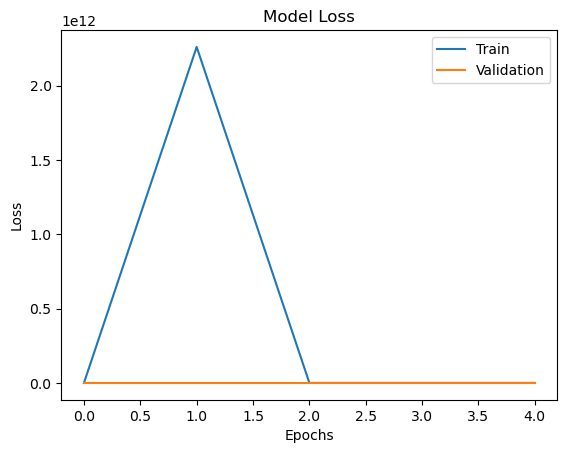

In [63]:
# Plot loss

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()